## Data
- ETF pair: GLD (SPDR Gold Trust) / GDX (VanEck Gold Miners ETF)
- Daily close prices via yfinance
- Period: 2019-2025


## 1. Price Series and Visual Inspection

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


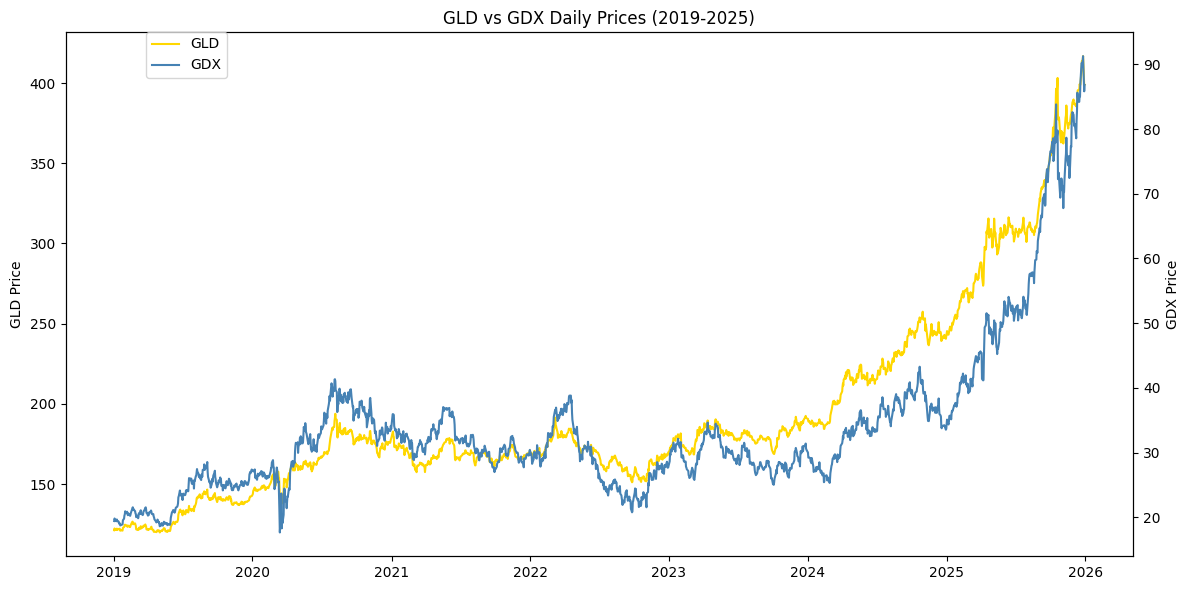

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

gld = yf.download('GLD', start='2019-01-01', end='2025-12-31')
gdx = yf.download('GDX', start='2019-01-01', end='2025-12-31')

gld.columns = gld.columns.get_level_values(0)
gdx.columns = gdx.columns.get_level_values(0)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(gld.index, gld['Close'], label='GLD', color='gold')
ax2 = ax1.twinx()
ax2.plot(gdx.index, gdx['Close'], label='GDX', color='steelblue')
ax1.set_ylabel('GLD Price')
ax2.set_ylabel('GDX Price')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.title('GLD vs GDX Daily Prices (2019-2025)')
plt.tight_layout()
plt.savefig('figures/gld_gdx_prices.png', dpi=150)
plt.show()

## 2. Stationarity Testing (ADF on Individual Series)

In [2]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'ADF Test: {name}')
    print(f'  Test Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.4f}')
    print(f'  Lags Used: {result[2]}')
    print(f'  Stationary: {"Yes" if result[1] < 0.05 else "No"}')
    print()

adf_test(gld['Close'], 'GLD Price Level')
adf_test(gdx['Close'], 'GDX Price Level')

ADF Test: GLD Price Level
  Test Statistic: 3.3786
  p-value: 1.0000
  Lags Used: 7
  Stationary: No

ADF Test: GDX Price Level
  Test Statistic: 2.2698
  p-value: 0.9989
  Lags Used: 25
  Stationary: No



### ADF Results
- GLD: Test Statistic = 3.379, p-value = 1.000. Non-stationary.
- GDX: Test Statistic = 2.270, p-value = 0.999. Non-stationary.

Both series are clearly non-stationary (positive test statistics, p-values at 1.0). This is a necessary condition for cointegration: if a linear combination of two non-stationary series is stationary, they are cointegrated.


## 3. Spread Construction

Beta: 0.1906
Intercept: -3.1914
R-squared: 0.8776


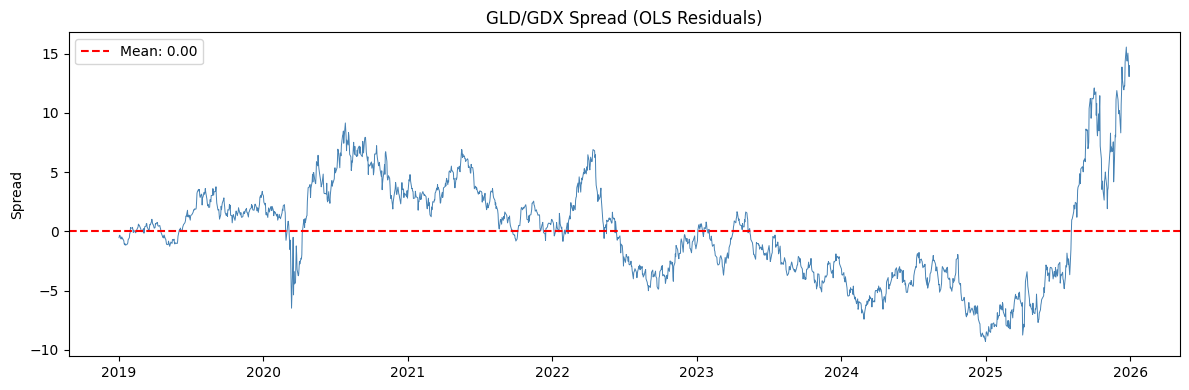

In [3]:
import statsmodels.api as sm

X = sm.add_constant(gld['Close'])
model = sm.OLS(gdx['Close'], X).fit()
print(f'Beta: {model.params.iloc[1]:.4f}')
print(f'Intercept: {model.params.iloc[0]:.4f}')
print(f'R-squared: {model.rsquared:.4f}')

spread = gdx['Close'] - model.params.iloc[1] * gld['Close'] - model.params.iloc[0]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(spread.index, spread, color='steelblue', linewidth=0.7)
ax.axhline(y=spread.mean(), color='red', linestyle='--', label=f'Mean: {spread.mean():.2f}')
ax.set_title('GLD/GDX Spread (OLS Residuals)')
ax.set_ylabel('Spread')
ax.legend()
plt.tight_layout()
plt.savefig('figures/gld_gdx_spread.png', dpi=150)
plt.show()

## 4. Engle-Granger Two-Step Test
### Step 1: OLS Regression
Completed above. GDX regressed on GLD.

### Step 2: ADF Test on Residuals
If the spread (OLS residuals) is stationary, the two series are cointegrated.

In [4]:
adf_test(spread, 'GLD/GDX Spread (OLS Residuals)')

ADF Test: GLD/GDX Spread (OLS Residuals)
  Test Statistic: -1.5608
  p-value: 0.5032
  Lags Used: 20
  Stationary: No

